In [0]:
import mlflow
mlflow.end_run()

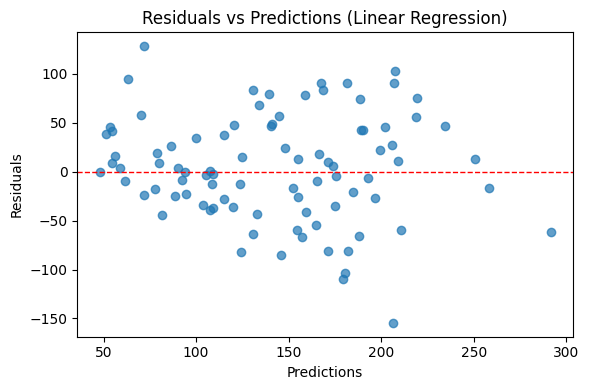

Metrics -> RMSE: 53.8534, MAE: 42.7941, R2: 0.4526
Experiment fully tracked with plot, CSV, and signature!


In [0]:
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from mlflow.models.signature import infer_signature

# Clean up any stuck runs from previous crashes
mlflow.end_run() 

# 1. Load Data
data = load_diabetes()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 2. Build Pipeline
model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

# 3. Start MLflow Tracking
with mlflow.start_run(run_name="linear-regression-diabetes") as run:
    
    # ---- Log Params
    mlflow.log_params({
        "model_type": "LinearRegression",
        "dataset": "sklearn.diabetes",
        "test_size": 0.20,
        "random_state": 42,
        "standardize": True
    })

    # ---- Train
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    # ---- Calculate Metrics (FIXED RMSE math)
    rmse = float(np.sqrt(mean_squared_error(y_test, preds)))
    mae  = float(mean_absolute_error(y_test, preds))
    r2   = float(r2_score(y_test, preds))
    
    # ---- Log Metrics
    mlflow.log_metrics({"rmse": rmse, "mae": mae, "r2": r2})
    
    # ---- Log Model with Signature (FIXED WARNING)
    signature = infer_signature(X_train, preds)
    mlflow.sklearn.log_model(model, "model", signature=signature)
    
    # ---- Log Coefficients to CSV
    coefs = pd.DataFrame({
        "feature": X.columns,
        "coef": model.named_steps["regressor"].coef_
    })
    coefs.to_csv("coefficients.csv", index=False)
    mlflow.log_artifact("coefficients.csv", artifact_path="model_info")

    # ---- Generate and Log Residuals Plot
    residuals = y_test.values - preds
    plt.figure(figsize=(6,4))
    plt.scatter(preds, residuals, alpha=0.7)
    plt.axhline(0, color="red", linestyle="--", linewidth=1)
    plt.title("Residuals vs Predictions (Linear Regression)")
    plt.xlabel("Predictions")
    plt.ylabel("Residuals")
    plt.tight_layout()
    
    plt.savefig("residuals.png")
    plt.show() # Displays plot in the notebook
    plt.close()
    
    mlflow.log_artifact("residuals.png")
    
    # ---- Final Output
    print(f"Metrics -> RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")
    print("Experiment fully tracked with plot, CSV, and signature!")